## imports

In [1]:
from auto_flow_pipeline.figures.auto_v_human import bland_altman_plot, filter_dataframe, create_bland_altman_2x3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

In [2]:
SAVE_PATH = "/home/ayeluru/mnt/maxwell/projects/Aorta_pulmonary_artery_localization/ge_testing/figures/"

# loading data

In [3]:
HUMAN_FLOW_MEASUREMENTS_PATH_OG = '/maxwell-projects/Aorta_pulmonary_artery_localization/ge_testing/flow_measurements_og.csv'
df_og = pd.read_csv(HUMAN_FLOW_MEASUREMENTS_PATH_OG)

HUMAN_FLOW_MEASUREMENTS_PATH_GE = '/maxwell-projects/Aorta_pulmonary_artery_localization/ge_testing/flow_measurements_human_ge.csv'
df_h_ge = pd.read_csv(HUMAN_FLOW_MEASUREMENTS_PATH_GE)

AUTO_FLOW_MEASUREMENTS_PATH_GE = '/maxwell-projects/Aorta_pulmonary_artery_localization/ge_testing/flow_measurements_autoflow_ge.csv'
df_a_ge = pd.read_csv(AUTO_FLOW_MEASUREMENTS_PATH_GE)

df_ge = pd.merge(df_h_ge, df_a_ge, left_on='Phonetic', right_on='patient_id')
df_ge = df_ge.sort_values(by='Phonetic')


# Figures

## bland altman AutoFlow vs gt og all

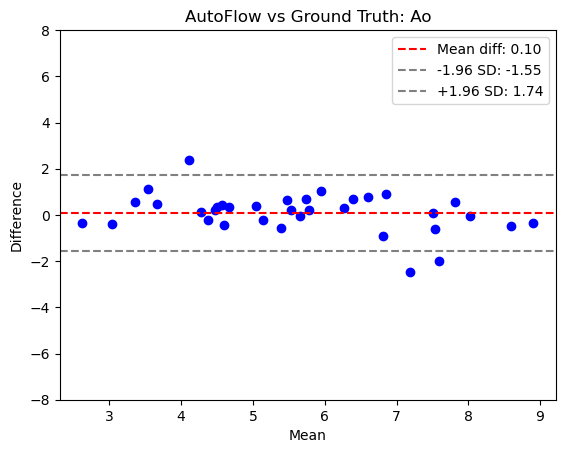

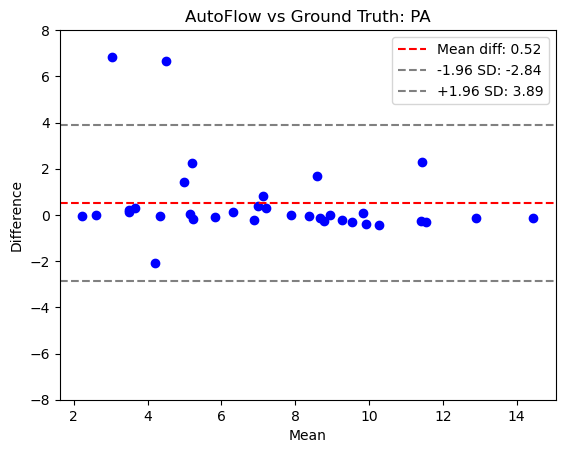

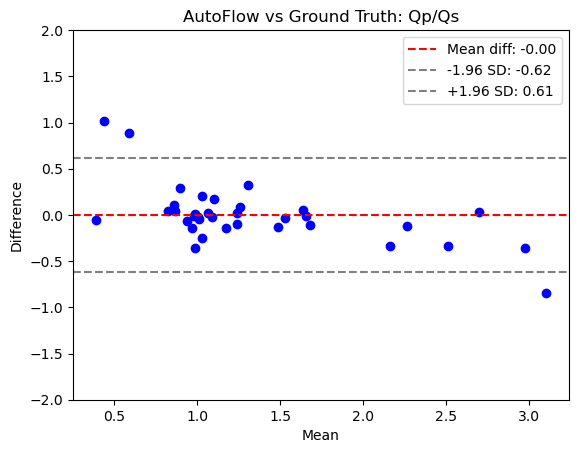

In [4]:
### AutoFlow vs GT
%matplotlib inline

all_RADS = ['Ao', 'PA', 'Qp/Qs']
for RAD in all_RADS:

    CNN = RAD + '_auto'
    GT = RAD + '_AH'
    gt = df_og[GT]
    comp = df_og[CNN]

    fig, ax = plt.subplots()
    if RAD in ['Ao', 'PA']:
        ylim = (-8, 8)  # Custom limit for Ao and PA
    else:
        ylim = (-2, 2)  # Different limit for Qp/Qs

    bland_altman_plot(gt, comp, ax=ax, title='AutoFlow vs Ground Truth: ' + RAD, ylim=ylim)
    plt.show()


## bland altman autoflow vs gt og filtered

In [5]:
filtered_df_Ao = filter_dataframe(df_og, 'Ao_auto_std', 0.5)
filtered_df_PA = filter_dataframe(df_og, 'PA_auto_std', 0.5)
filtered_df_QpQs = filter_dataframe(filtered_df_Ao, 'PA_auto_std', 0.5)

print(len(filtered_df_Ao))
print(len(filtered_df_PA))
print(len(filtered_df_QpQs))

27
25
21


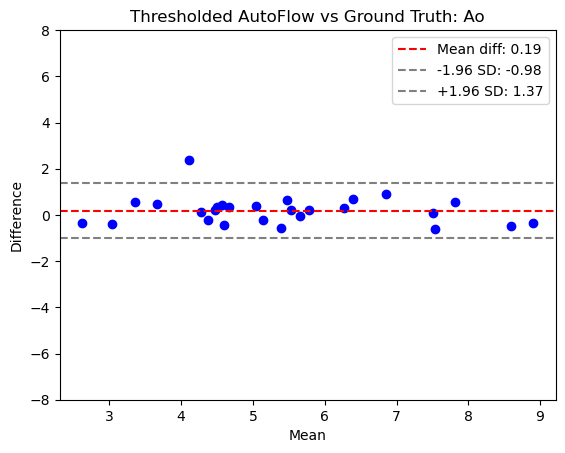

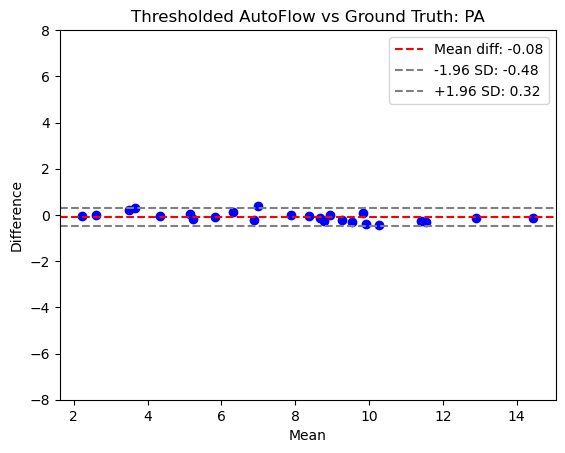

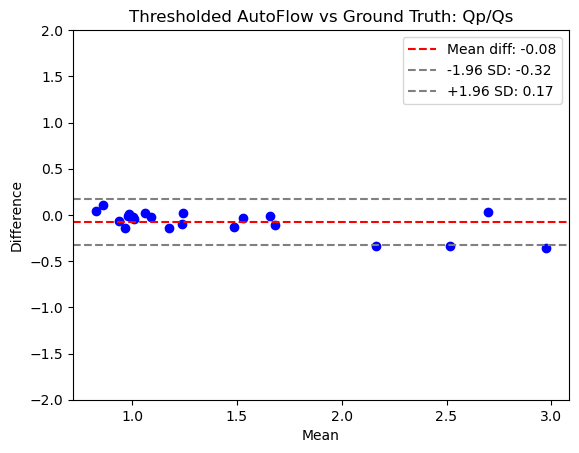

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

all_RADS = ['Ao', 'PA', 'Qp/Qs']
list_filtered = [filtered_df_Ao, filtered_df_PA, filtered_df_QpQs]
for i,RAD in enumerate(all_RADS):
    
    filtered_df_init = list_filtered[i]

    CNN = RAD + '_auto'
    GT = RAD + '_AH'
    gt = filtered_df_init[GT]
    comp = filtered_df_init[CNN]

    fig, ax = plt.subplots()
    if RAD in ['Ao', 'PA']:
        ylim = (-8, 8)  # Custom limit for Ao and PA
    else:
        ylim = (-2, 2)  # Different limit for Qp/Qs

    bland_altman_plot(gt, comp, ax=ax, title='Thresholded AutoFlow vs Ground Truth: ' + RAD, ylim=ylim)
    
    # # Show and/or save the plot
    # path = '/maxwell-projects/Aorta_pulmonary_artery_localization/testing_compiled_volumes/figures'
    # plt.savefig(os.path.join(path, 's3_' + str(i+3)+'.png'), dpi=300, bbox_inches='tight')
    plt.show()

## og all plots autoflow vs gt

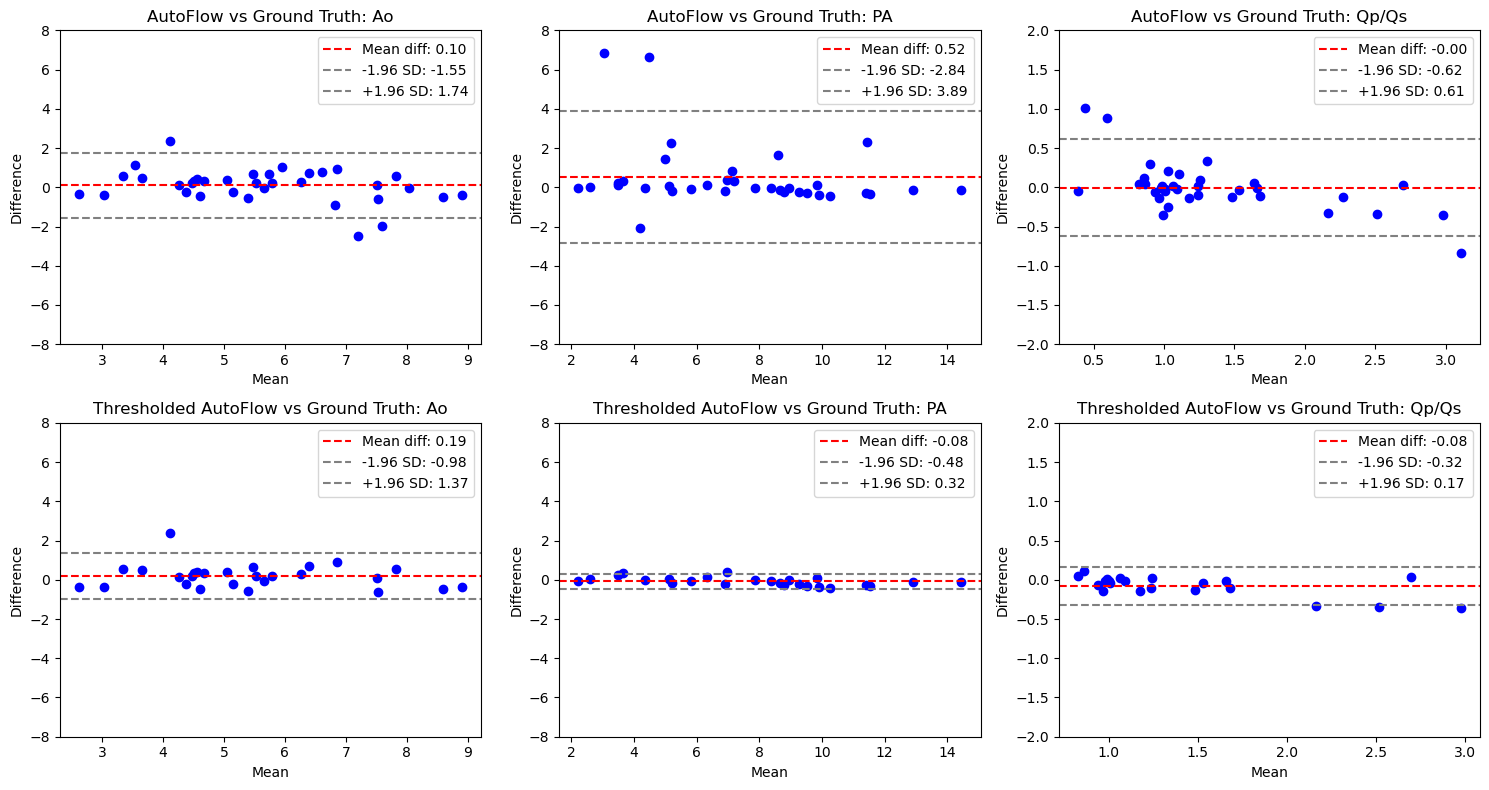

In [7]:
comp_suffix = '_auto'

fig, axes = create_bland_altman_2x3(
    df_og,
    comp_suffix=comp_suffix,
    bland_altman_plot_func=bland_altman_plot,
    filter_dataframe_func=filter_dataframe,  # your function
    threshold=0.5
)

plt.show()

fig.savefig(SAVE_PATH + f'bland-altman_og{comp_suffix}.png', dpi=300, bbox_inches='tight')


## og all plots readers vs gt

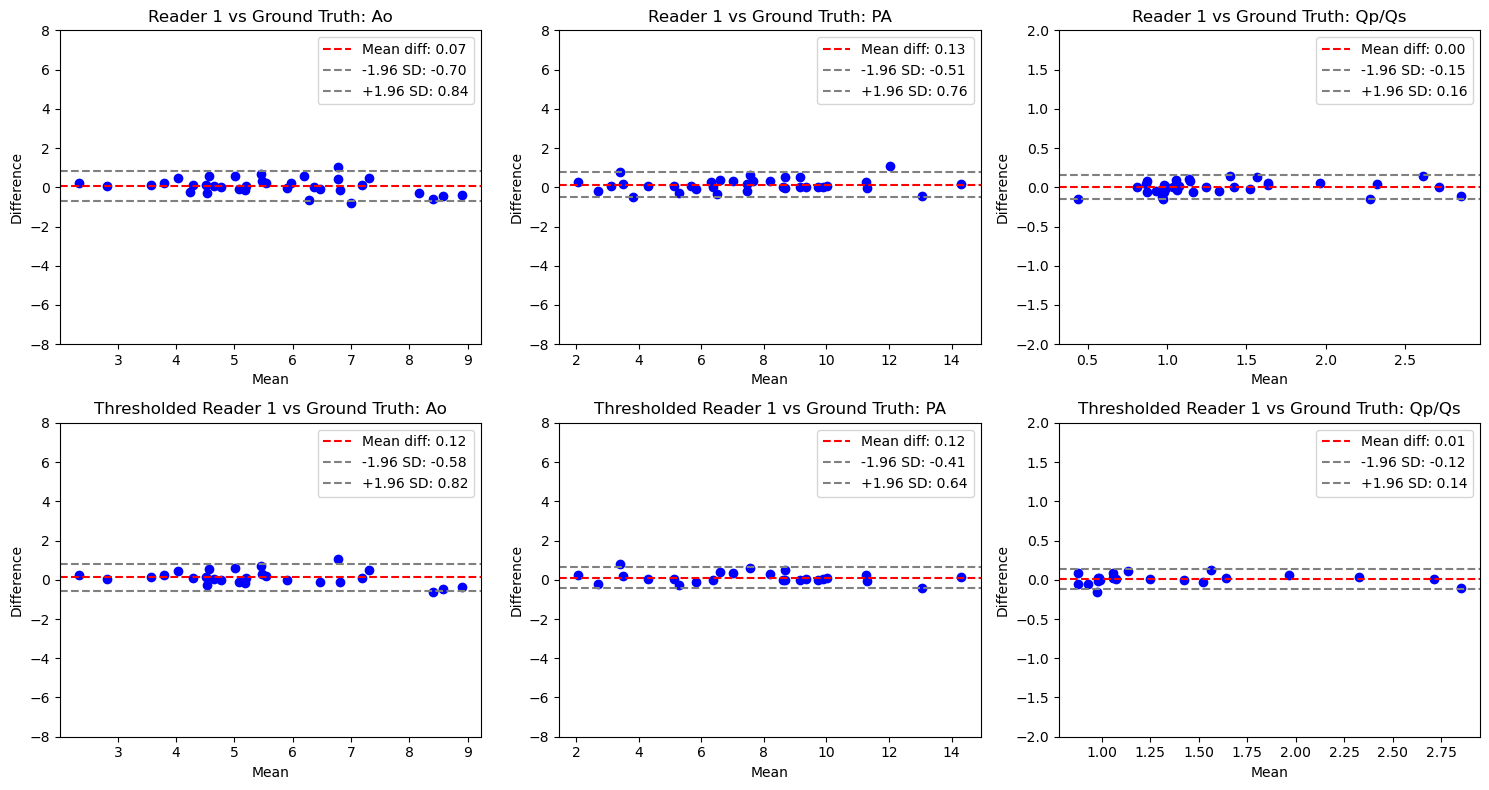

In [10]:
comp_suffix = '_PR'

fig, axes = create_bland_altman_2x3(
    df_og,
    comp_suffix=comp_suffix,
    bland_altman_plot_func=bland_altman_plot,
    filter_dataframe_func=filter_dataframe,  # your function
    threshold=0.5
)

plt.show()

fig.savefig(SAVE_PATH + f'bland-altman_og{comp_suffix}.png', dpi=300, bbox_inches='tight')


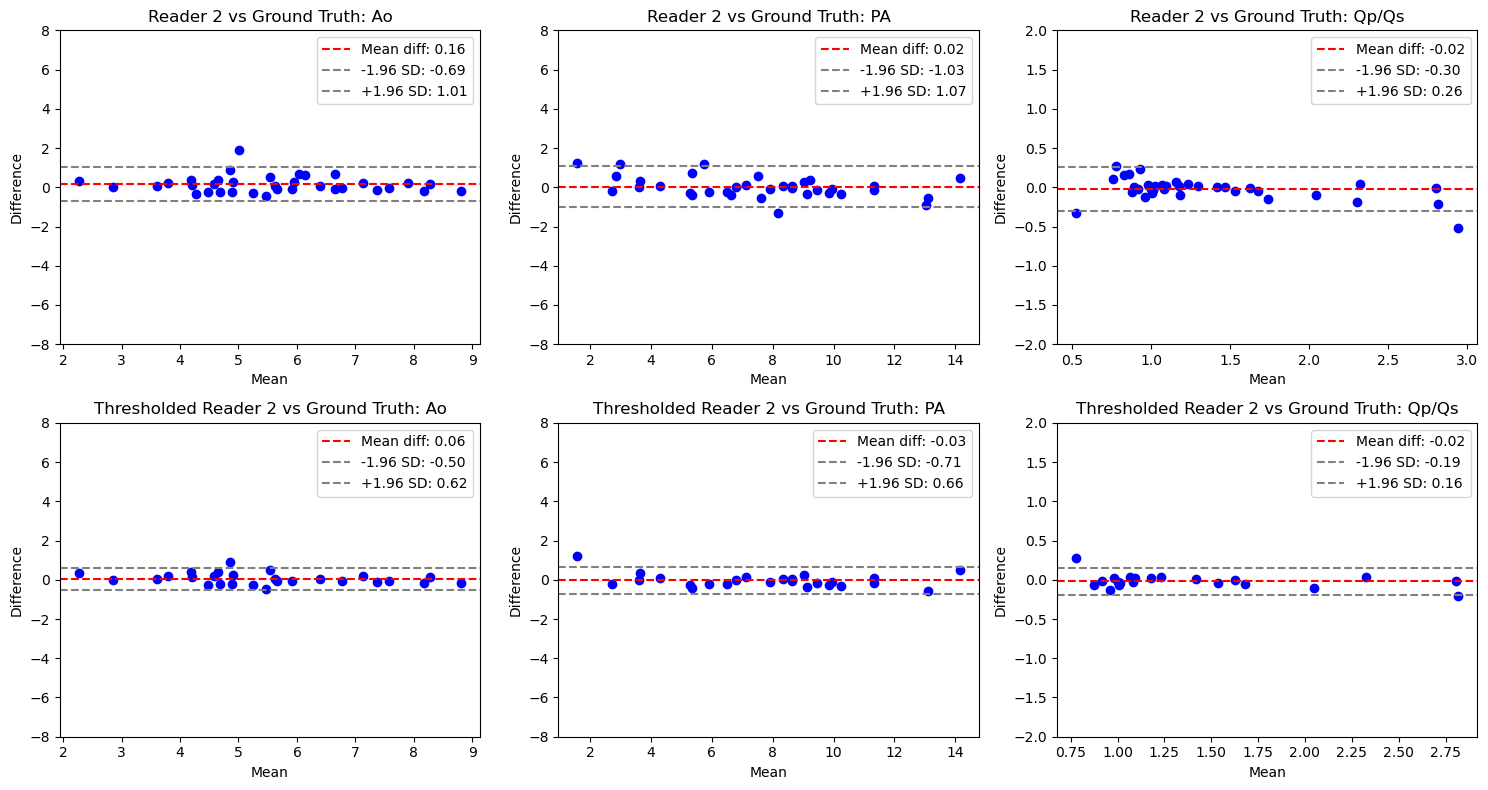

In [9]:
comp_suffix = '_LS'

fig, axes = create_bland_altman_2x3(
    df_og,
    comp_suffix=comp_suffix,
    bland_altman_plot_func=bland_altman_plot,
    filter_dataframe_func=filter_dataframe,  # your function
    threshold=0.5
)

plt.show()

fig.savefig(SAVE_PATH + f'bland-altman_og{comp_suffix}.png', dpi=300, bbox_inches='tight')


## ge all plots

### og all plots autoflow vs gt

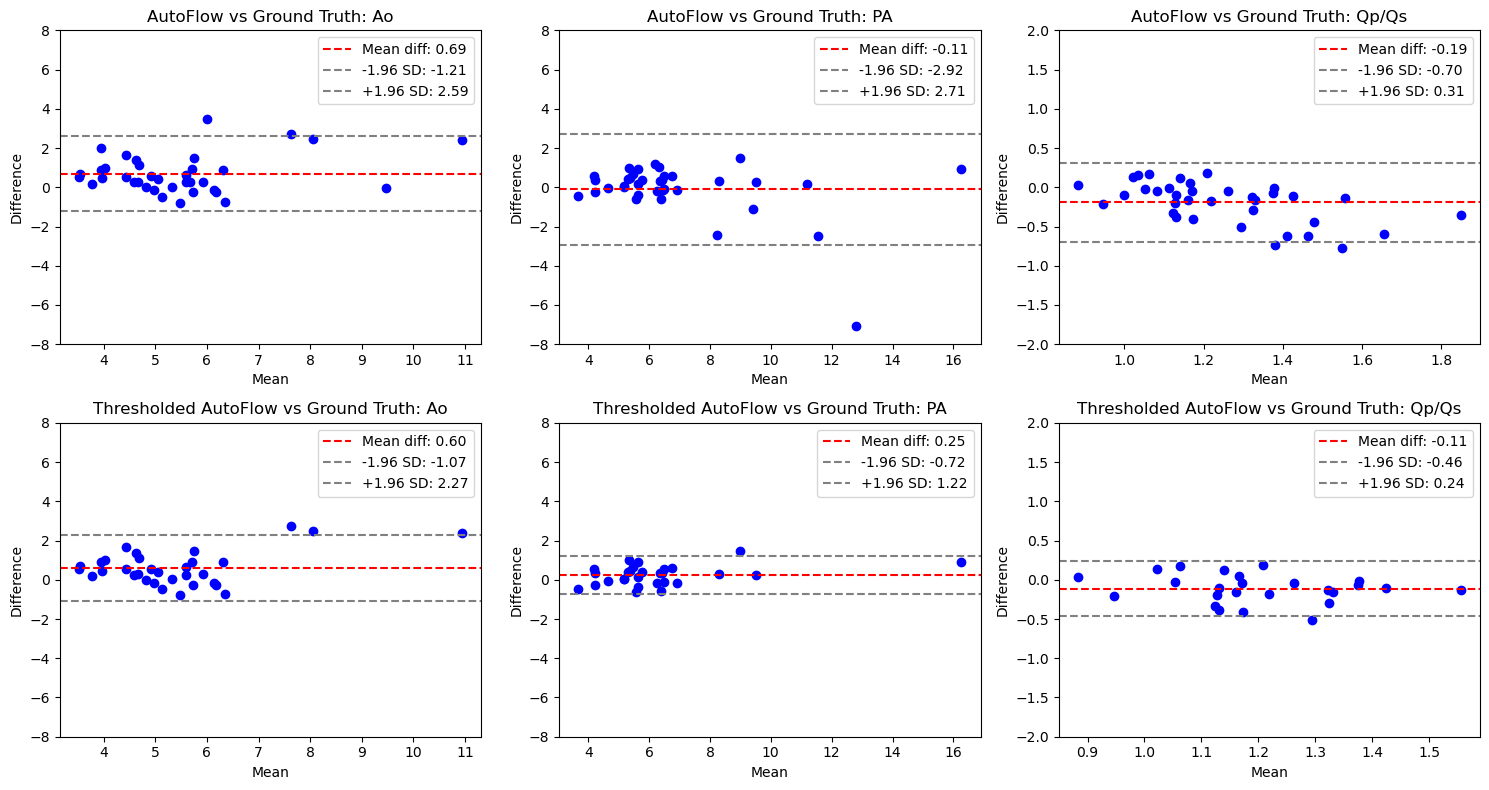

In [12]:
comp_suffix = '_auto'

fig, axes = create_bland_altman_2x3(
    df_ge,
    comp_suffix=comp_suffix,
    bland_altman_plot_func=bland_altman_plot,
    filter_dataframe_func=filter_dataframe,  # your function
    threshold=0.5
)

plt.show()

fig.savefig(SAVE_PATH + f'bland-altman_ge{comp_suffix}.png', dpi=300, bbox_inches='tight')


### og all plots readers vs gt

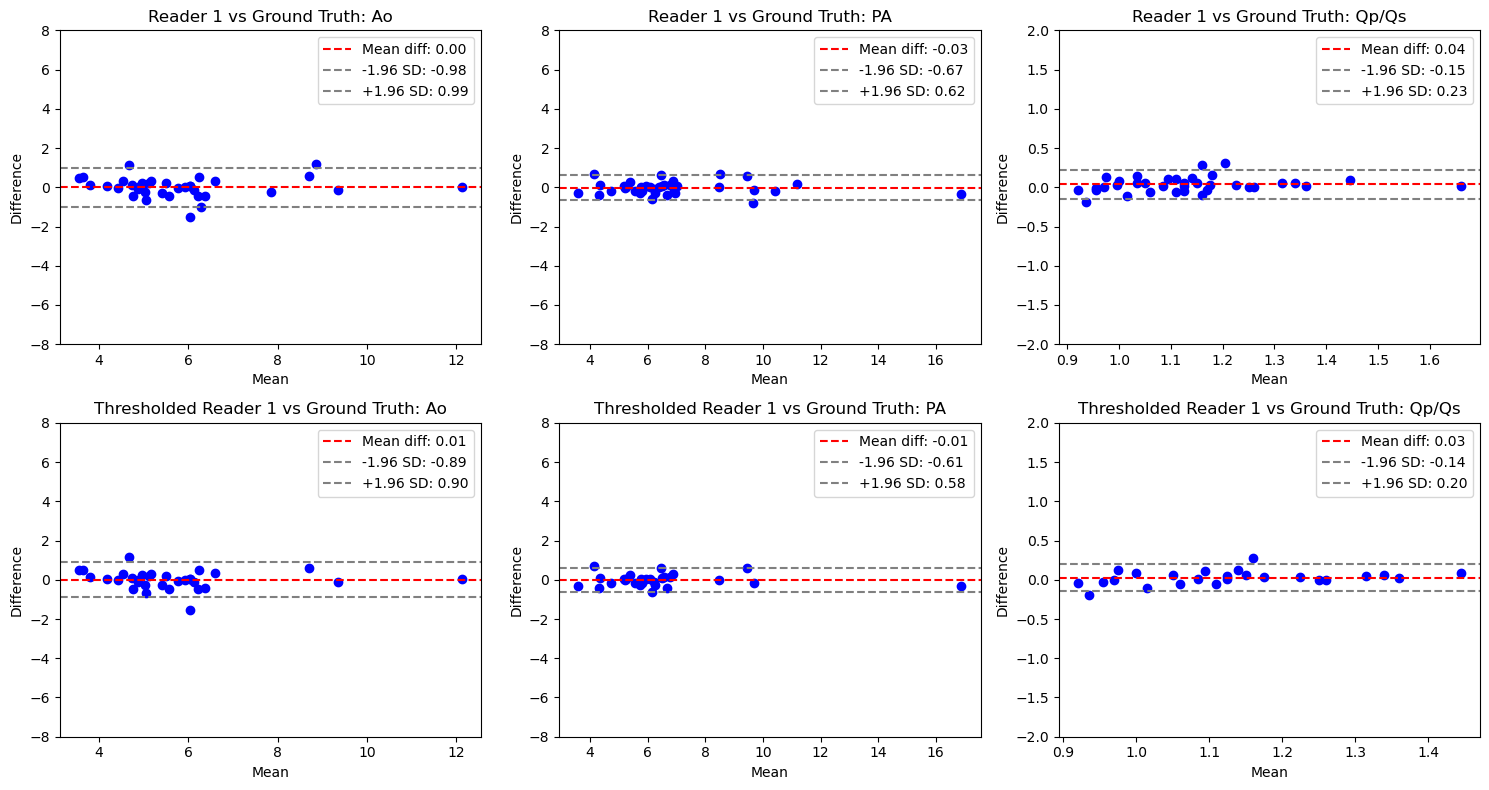

In [13]:
comp_suffix = '_PR'

fig, axes = create_bland_altman_2x3(
    df_ge,
    comp_suffix=comp_suffix,
    bland_altman_plot_func=bland_altman_plot,
    filter_dataframe_func=filter_dataframe,  # your function
    threshold=0.5
)

plt.show()

fig.savefig(SAVE_PATH + f'bland-altman_ge{comp_suffix}.png', dpi=300, bbox_inches='tight')


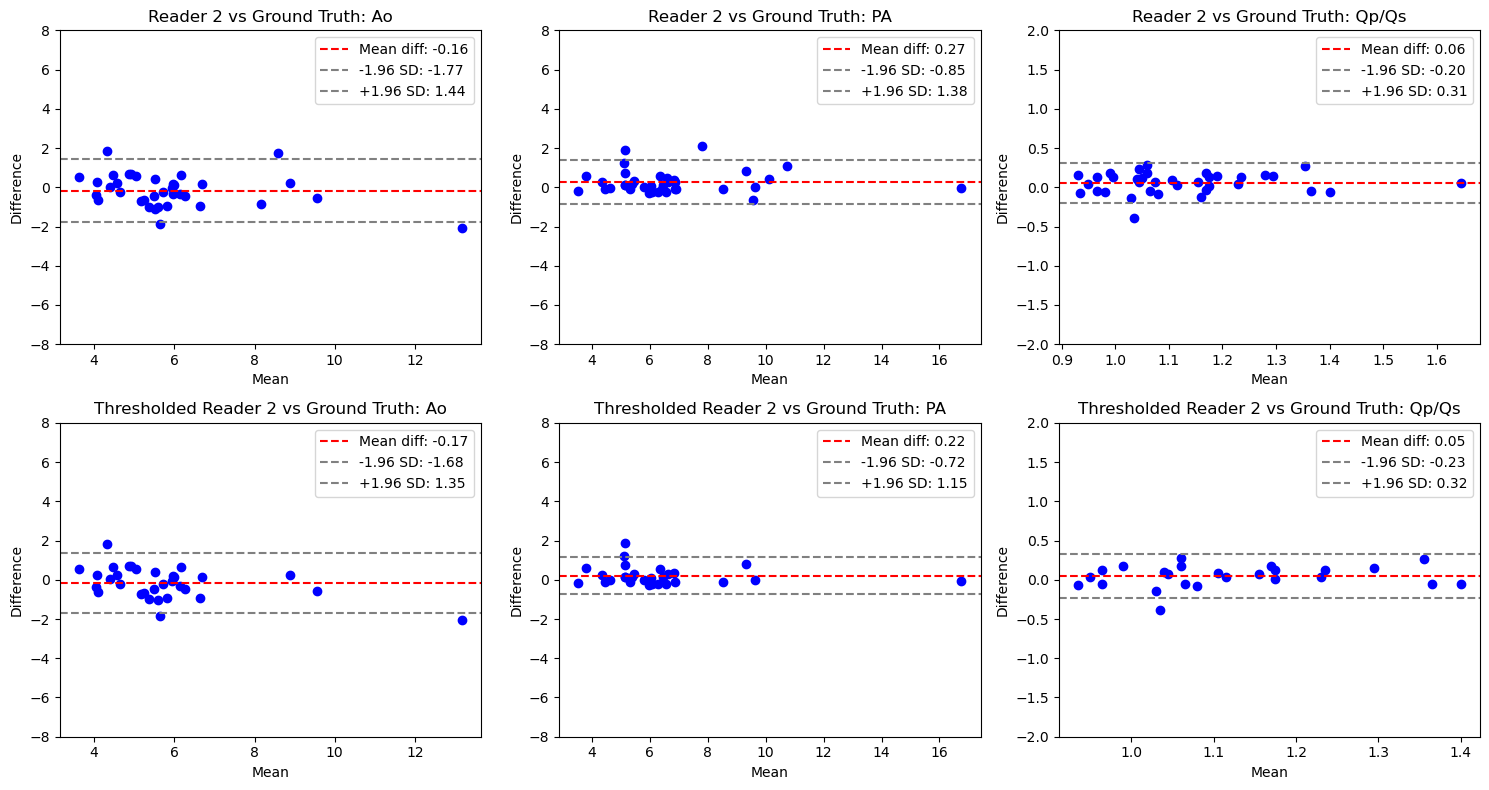

In [14]:
comp_suffix = '_LS'

fig, axes = create_bland_altman_2x3(
    df_ge,
    comp_suffix=comp_suffix,
    bland_altman_plot_func=bland_altman_plot,
    filter_dataframe_func=filter_dataframe,  # your function
    threshold=0.5
)

plt.show()

fig.savefig(SAVE_PATH + f'bland-altman_ge{comp_suffix}.png', dpi=300, bbox_inches='tight')
